## Text Classification using Machine Learning

This project builds a text classification system to categorize messages into multiple classes such as work, personal, spam, promotion and updates using classic machine learning models.

In [47]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve






## Datasets

The datasets consist of manually created text messages categorized into the said 5 classes.

A hard dataset was created with ambiguous tricky messages. This dataset tests how well the models handle real-world complexity beyond simple patterns.

In addition to the hard dataset, a balanced dataset was created to ensure equal representation of all categories







In [48]:

df = pd.read_csv("emails.csv")
df = df.drop_duplicates()
eval_df = pd.read_csv("eval_set_hard.csv")
eval_df = eval_df.drop_duplicates()
eval_data_df = pd.read_csv("eval_data_balanced.csv")
eval_data_df = eval_data_df.drop_duplicates()


## Text Preprocessing

The text data is cleaned and prepared for training:

Lowercasing text
Removing unncessary characters

In [49]:


def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & numbers
    return text

df["clean_text"] = df["text"].apply(clean_text)
eval_df["clean_text"] = eval_df["text"].apply(clean_text)
eval_data_df["clean_text"] = eval_data_df["text"].apply(clean_text)

df.head()

,text,label,clean_text
0,Let's schedule a meeting for tomorrow at 10am,work,lets schedule a meeting for tomorrow at am
1,Please find the attached report for your review,work,please find the attached report for your review
2,Can you update me on the project status?,work,can you update me on the project status
3,We need to finalize the budget by Friday,work,we need to finalize the budget by friday
4,Reminder: team standup at 9am,work,reminder team standup at am


##Train-Test Split

In [50]:


X_train_text, X_test_text, y_train, y_test = train_test_split(df["clean_text"],df["label"], test_size=0.2)

Vectorization using TF-IDF

In [51]:


vectorizer = TfidfVectorizer()

X_train_uni = vectorizer.fit_transform(X_train_text)
X_test_uni = vectorizer.transform(X_test_text)

X_eval_tfidf_uni = vectorizer.transform(eval_df["clean_text"])
y_eval = eval_df["label"]

X_eval_b_tfidf_uni = vectorizer.transform(eval_data_df["clean_text"])
y_eval_b = eval_data_df["label"]


##Bigrams

In [52]:
vectorizer_bigram = TfidfVectorizer(ngram_range=(1,2))

X_train_bigram = vectorizer_bigram.fit_transform(X_train_text)
X_test_bigram = vectorizer_bigram.transform(X_test_text)



X_eval_bigram_tfidf = vectorizer_bigram.transform(eval_df["clean_text"])

X_eval_b_bigram_tfidf = vectorizer_bigram.transform(eval_data_df["clean_text"])

##Models

In [53]:


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_uni, y_train)

y_pred_lr = lr_model.predict(X_test_uni)

In [54]:


nb_model = MultinomialNB()
nb_model.fit(X_train_uni, y_train)

y_pred_nb = nb_model.predict(X_test_uni)

In [55]:


svm_model = LinearSVC()
svm_model.fit(X_train_uni, y_train)

y_pred_svm = svm_model.predict(X_test_uni)

##Models(Bigrams)

In [56]:
lr_bigram = LogisticRegression(max_iter=1000)
lr_bigram.fit(X_train_bigram, y_train)

y_pred_lr_bigram = lr_bigram.predict(X_test_bigram)

In [57]:
nb_bigram = MultinomialNB()
nb_bigram.fit(X_train_bigram, y_train)

y_pred_nb_bigram = nb_bigram.predict(X_test_bigram)

In [58]:
svm_bigram = LinearSVC()
svm_bigram.fit(X_train_bigram, y_train)

y_pred_svm_bigram = svm_bigram.predict(X_test_bigram)

##Model Evaluation

In [59]:


print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("Linear SVC:", accuracy_score(y_test, y_pred_svm))

Logistic Regression: 0.9141104294478528
Naive Bayes: 0.950920245398773
Linear SVC: 0.9447852760736196


##Bigram Model Evaluation

In [60]:
print("Logistic Regression bigram:", accuracy_score(y_test, y_pred_lr_bigram))
print("Naive Bayes bigram:", accuracy_score(y_test, y_pred_nb_bigram))
print("Linear SVC bigram:", accuracy_score(y_test, y_pred_svm_bigram))

Logistic Regression bigram: 0.9079754601226994
Naive Bayes bigram: 0.9202453987730062
Linear SVC bigram: 0.9202453987730062


##Hard Dataset Evaluation

In [61]:
y_pred_eval_lr = lr_model.predict(X_eval_tfidf_uni)
print("logistic regression accuracy: ", accuracy_score(y_eval, y_pred_eval_lr))

y_pred_eval_nb = nb_model.predict(X_eval_tfidf_uni)
print("Naive Bayes accuracy: ", accuracy_score(y_eval, y_pred_eval_nb))

y_pred_eval_svm = svm_model.predict(X_eval_tfidf_uni)
print("Linear SVC accuracy: ",accuracy_score(y_eval, y_pred_eval_svm))




logistic regression accuracy:  0.6
Naive Bayes accuracy:  0.54
Linear SVC accuracy:  0.66


In [62]:
y_pred_eval_lr_bigram = lr_bigram.predict(X_eval_bigram_tfidf)
print("logistic regression accuracy hard dataset bigram: ", accuracy_score(y_eval, y_pred_eval_lr_bigram))

y_pred_eval_nb_bigram = nb_bigram.predict(X_eval_bigram_tfidf)
print("Naive Bayes accuracy hard dataset bigram: ", accuracy_score(y_eval, y_pred_eval_nb_bigram))

y_pred_eval_svm_bigram = svm_bigram.predict(X_eval_bigram_tfidf)
print("Linear SVC accuracy hard dataset bigram: ",accuracy_score(y_eval, y_pred_eval_svm_bigram))



logistic regression accuracy hard dataset bigram:  0.58
Naive Bayes accuracy hard dataset bigram:  0.5
Linear SVC accuracy hard dataset bigram:  0.64


##Balanced Dataset Evaluation

In [63]:
y_pred_eval_b_lr = lr_model.predict(X_eval_b_tfidf_uni)
print("logistic regression accuracy: ", accuracy_score(y_eval_b, y_pred_eval_b_lr))

y_pred_eval_b_nb = nb_model.predict(X_eval_b_tfidf_uni)
print("Naive Bayes accuracy: ", accuracy_score(y_eval_b, y_pred_eval_b_nb))

y_pred_eval_b_svm = svm_model.predict(X_eval_b_tfidf_uni)
print("Linear SVC accuracy: ",accuracy_score(y_eval_b, y_pred_eval_b_svm))

logistic regression accuracy:  0.8857142857142857
Naive Bayes accuracy:  0.819047619047619
Linear SVC accuracy:  0.9142857142857143


In [64]:
y_pred_bal_lr_bi = lr_bigram.predict(X_eval_b_bigram_tfidf)
print("logistic regression accuracy: ", accuracy_score(y_eval_b, y_pred_bal_lr_bi))

y_pred_bal_nb_bi = nb_bigram.predict(X_eval_b_bigram_tfidf)
print("Naive Bayes accuracy: ", accuracy_score(y_eval_b, y_pred_bal_nb_bi))

y_pred_bal_svm_bi = svm_bigram.predict(X_eval_b_bigram_tfidf)
print("Linear SVC accuracy: ",accuracy_score(y_eval_b, y_pred_bal_svm_bi))

logistic regression accuracy:  0.8571428571428571
Naive Bayes accuracy:  0.819047619047619
Linear SVC accuracy:  0.8476190476190476


##Confusion Matrix

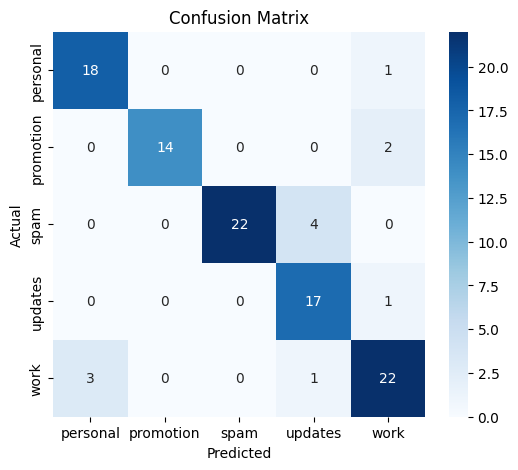

In [65]:


cm = confusion_matrix(y_eval_b, y_pred_eval_b_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##Learning Curve Analysis

In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC()
}

results = {}

for name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_train_uni,
        y_train,
        cv=5,
        train_sizes=[0.1, 0.3, 0.5, 0.8, 1.0],
        scoring="accuracy"
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    results[name] = {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "test_mean": test_mean
    }

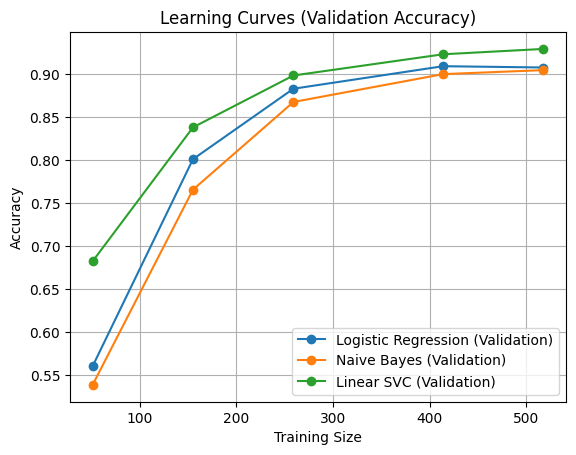

In [67]:
plt.figure()

for name, res in results.items():
    plt.plot(res["train_sizes"], res["test_mean"], marker='o', label=f"{name} (Validation)")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curves (Validation Accuracy)")
plt.legend()
plt.grid()

plt.show()

##Training Curve Analysis

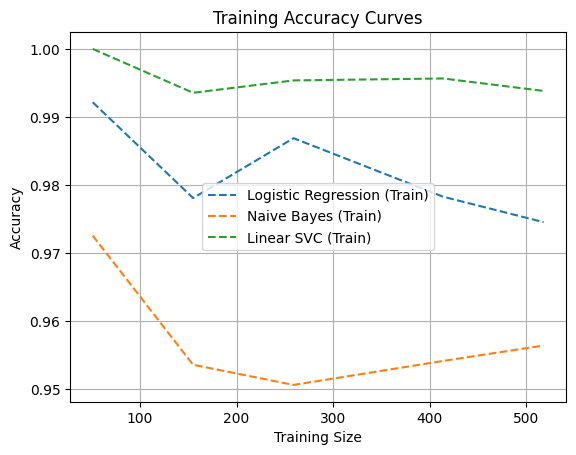

In [68]:
plt.figure()

for name, res in results.items():
    plt.plot(res["train_sizes"], res["train_mean"], linestyle='--', label=f"{name} (Train)")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curves")
plt.legend()
plt.grid()

plt.show()

# New Section